  Customer_ID  Gender  Age    Education Employment_Status Marital_Status  \
0    CUST1001    Male   37       Master          Employed         Single   
1    CUST1002  Female   29  High School     Self-Employed        Married   
2    CUST1003  Female   53     Bachelor          Employed        Married   
3    CUST1004  Female   40     Bachelor          Employed        Married   
4    CUST1005    Male   33  High School     Self-Employed        Married   

   Dependents  Annual_Income  Credit_Score  Existing_Loans  ... Interest_Rate  \
0           4        1336618           799               0  ...          8.43   
1           0        1282686           645               4  ...         12.20   
2           0        2305480           687               2  ...         12.96   
3           3        1287810           764               4  ...         12.20   
4           2         992283           629               4  ...         11.29   

  Monthly_Installment  Debt_to_Income_Ratio  Employment_

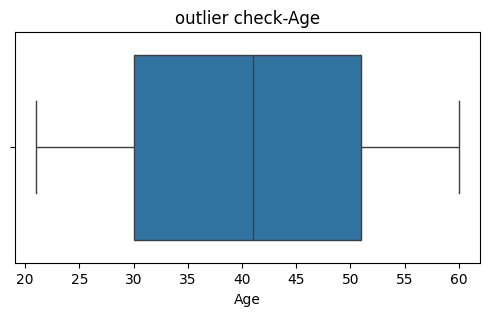

(500, 24)
0
0


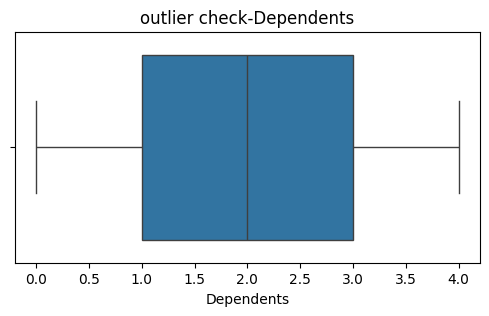

(500, 24)
0
0


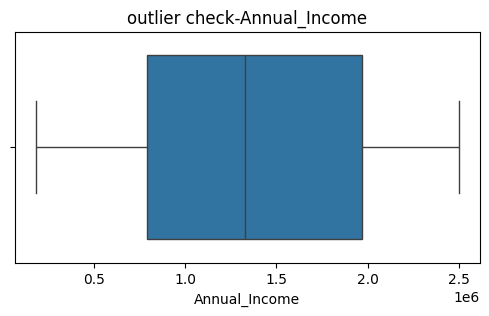

(500, 24)
0
0


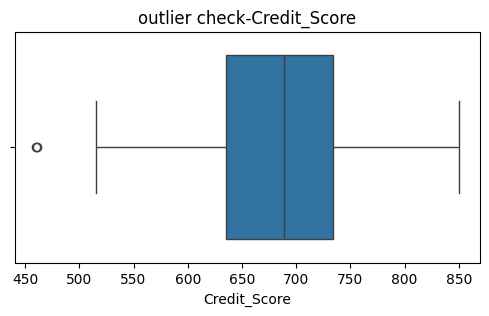

(500, 24)
0
0


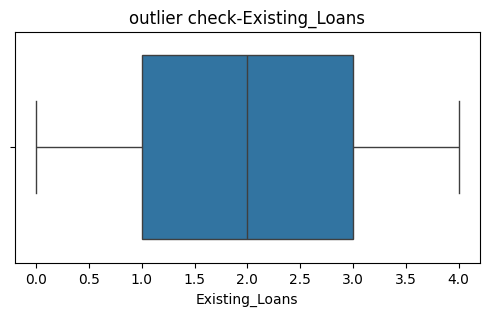

(500, 24)
0
0


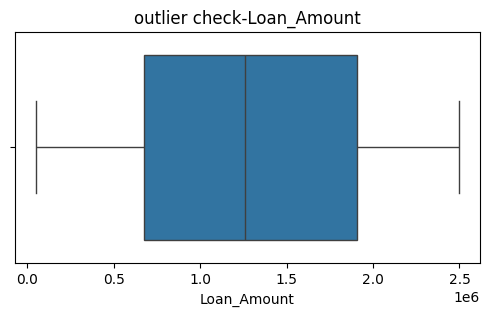

(500, 24)
0
0


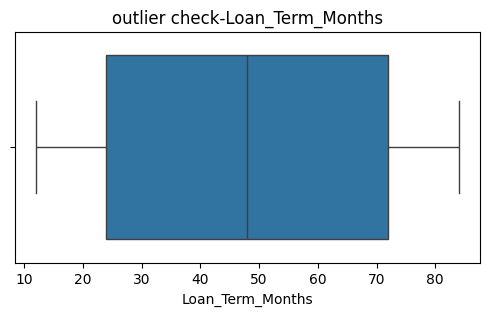

(500, 24)
0
0


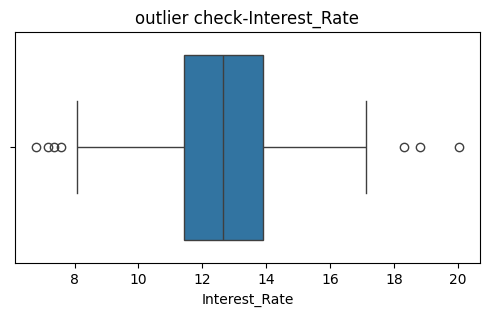

(500, 24)
0
0


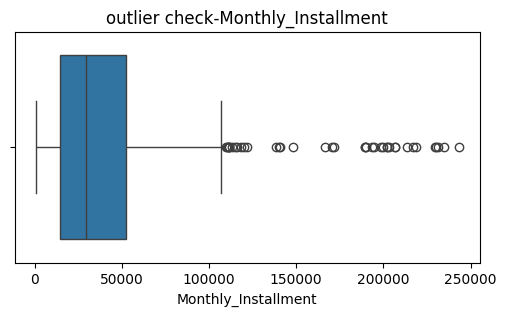

(500, 24)
0
0


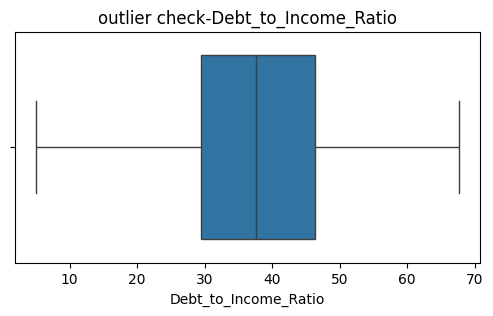

(500, 24)
0
0


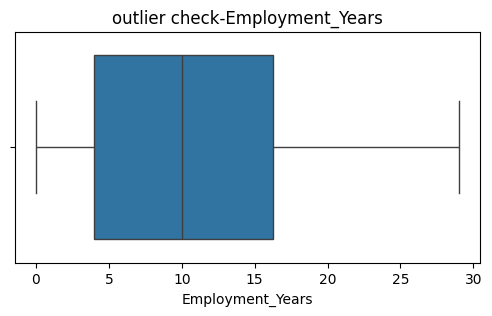

(500, 24)
0
0


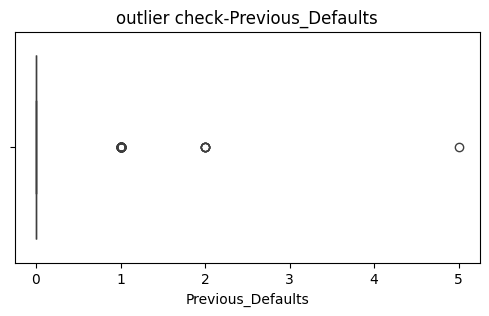

(500, 24)
0
0
500
500
0
224
0.0 2
685.492 2
1280249.914 2
12.642259999999998 2
37.76764 2
Loan_Type
Personal     160
Home         125
Auto         100
Business      71
Education     44
Name: count, dtype: int64
Region
Central    116
West       114
East        97
North       89
South       84
Name: count, dtype: int64

28. Default Rate by Loan Type:
Loan_Type
Auto         60.00
Business     50.70
Education    59.09
Home         56.00
Personal     52.50
Name: Default_Status, dtype: float64

29. Default Rate by Employment Status:
Employment_Status
Business         56.52
Employed         53.55
Self-Employed    52.69
Unemployed       72.73
Name: Default_Status, dtype: float64

30. Default Rate by Education:
Education
Bachelor       56.67
Diploma        64.44
High School    58.51
Master         49.64
Phd            35.71
Name: Default_Status, dtype: float64

31. Default Rate by Property Ownership:
Property_Ownership
Family       57.89
Mortgaged    51.28
Owned        54.30
Rented       57.66


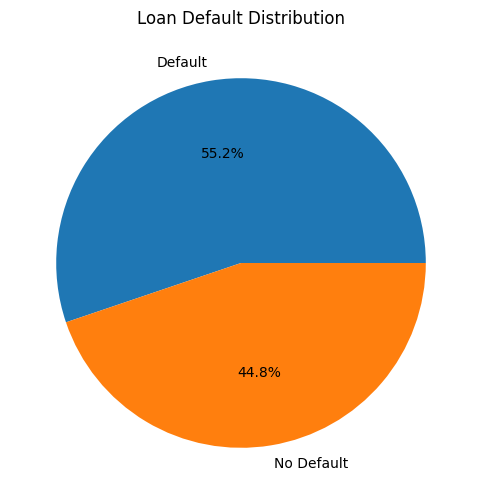

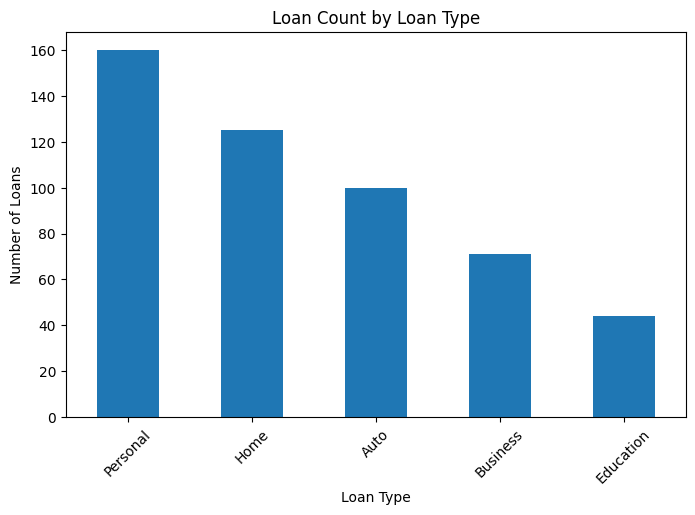

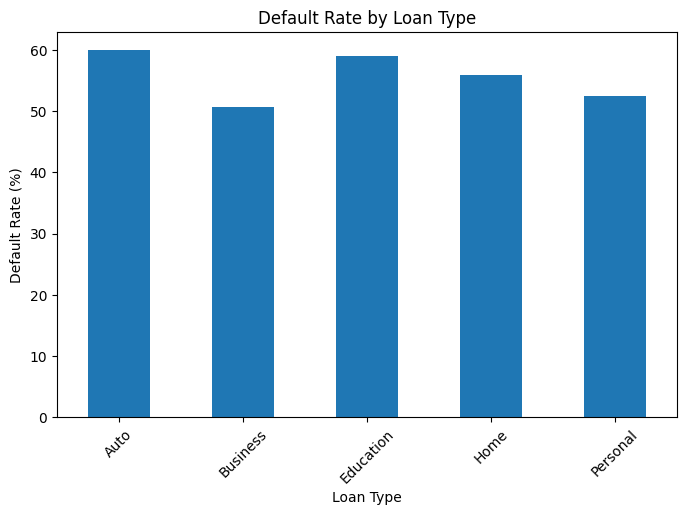

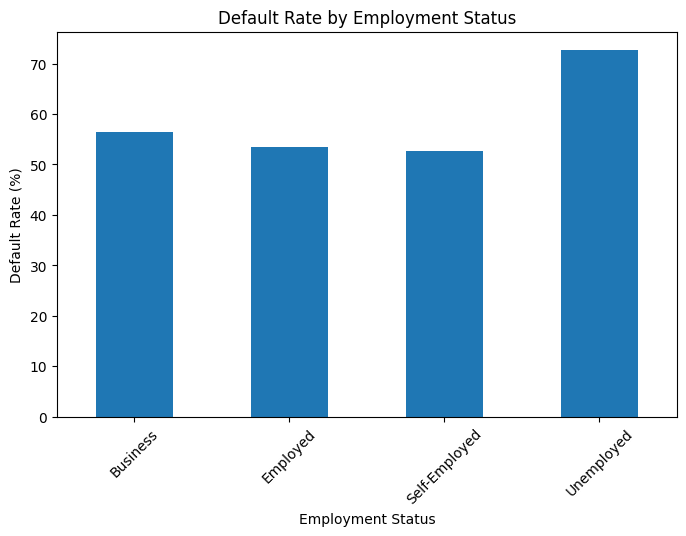

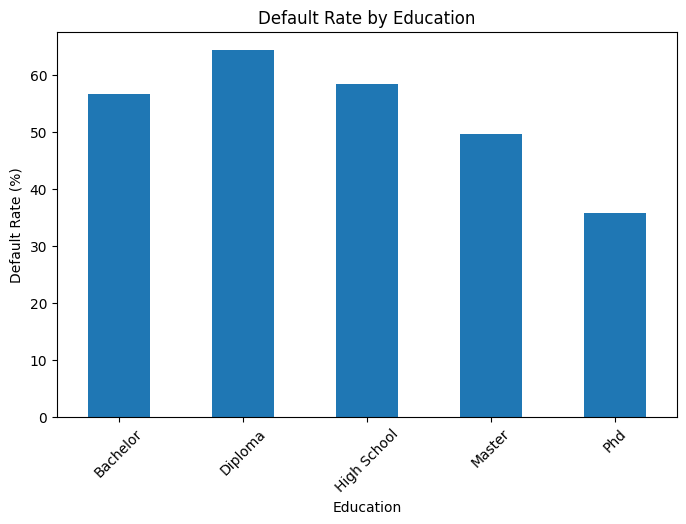

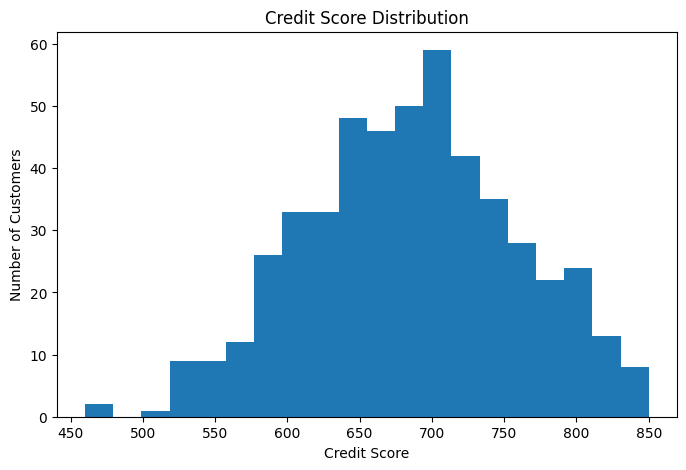

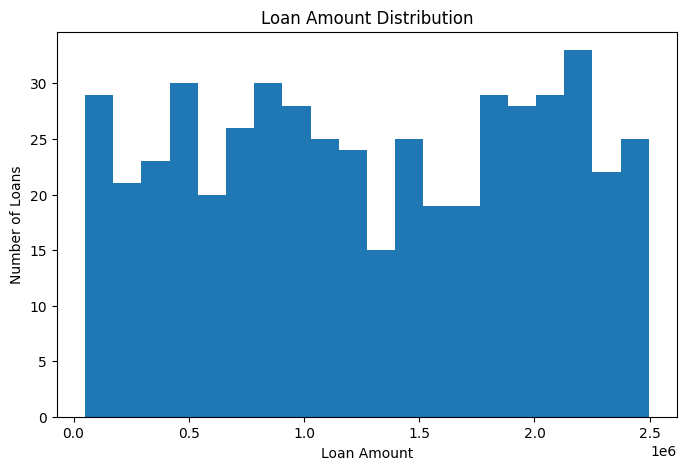

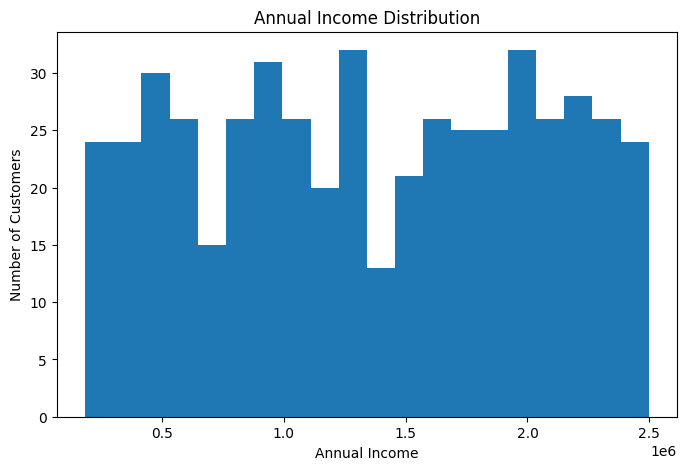

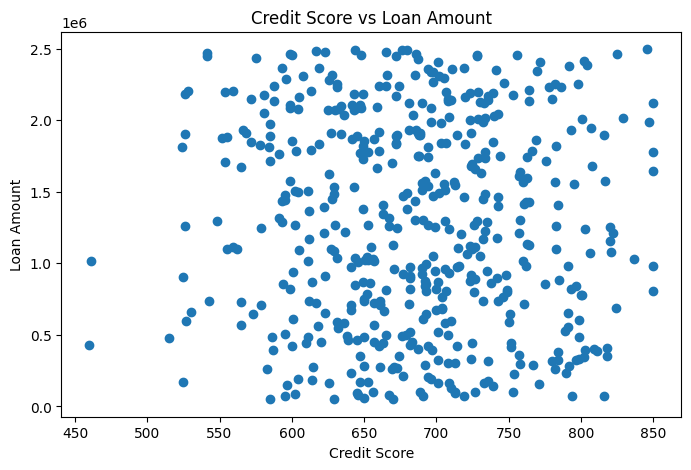

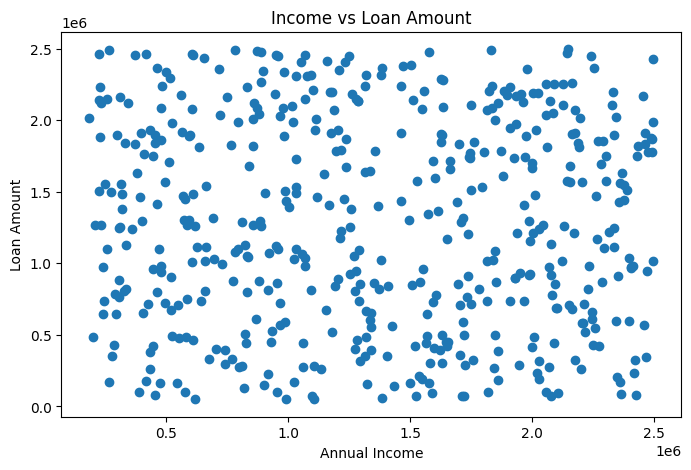

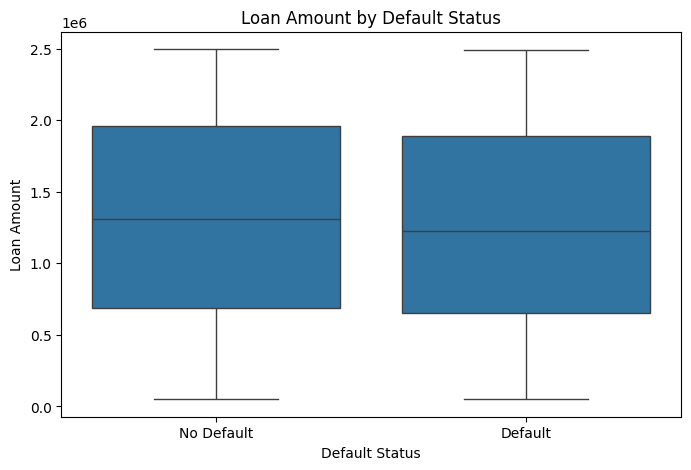

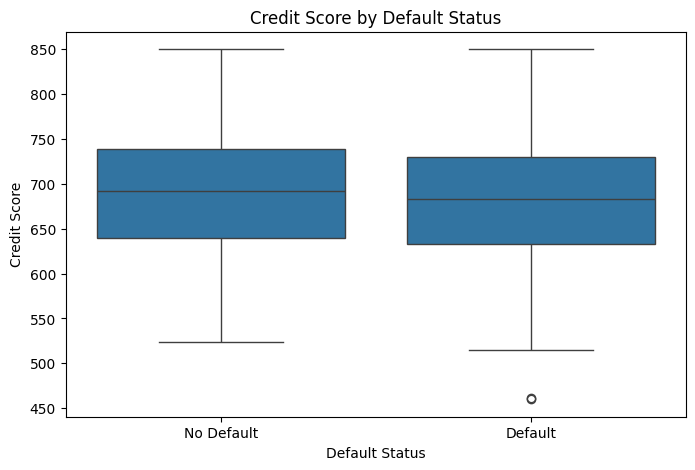

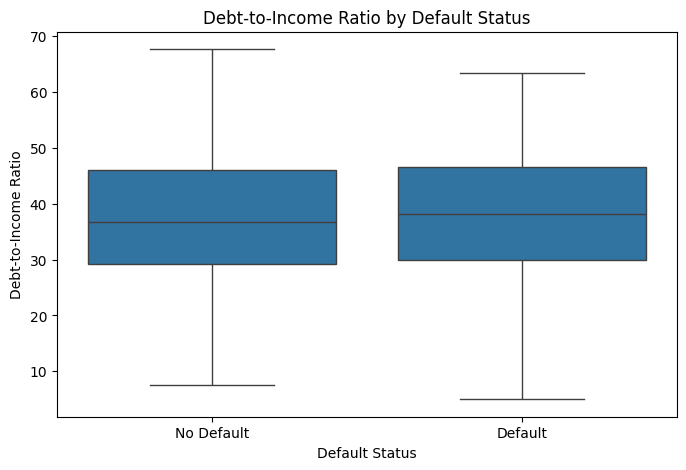

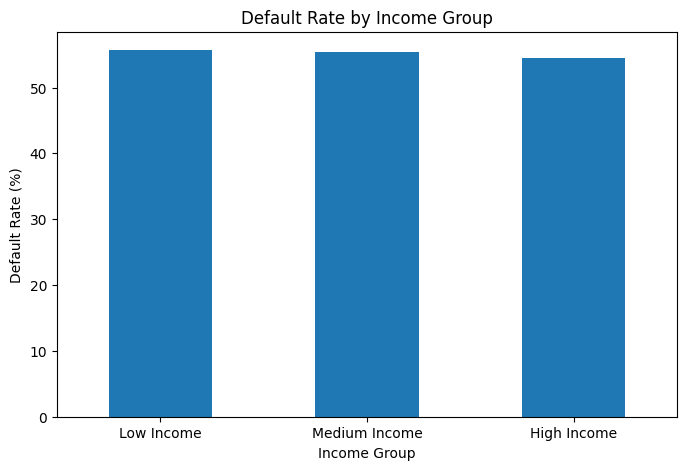

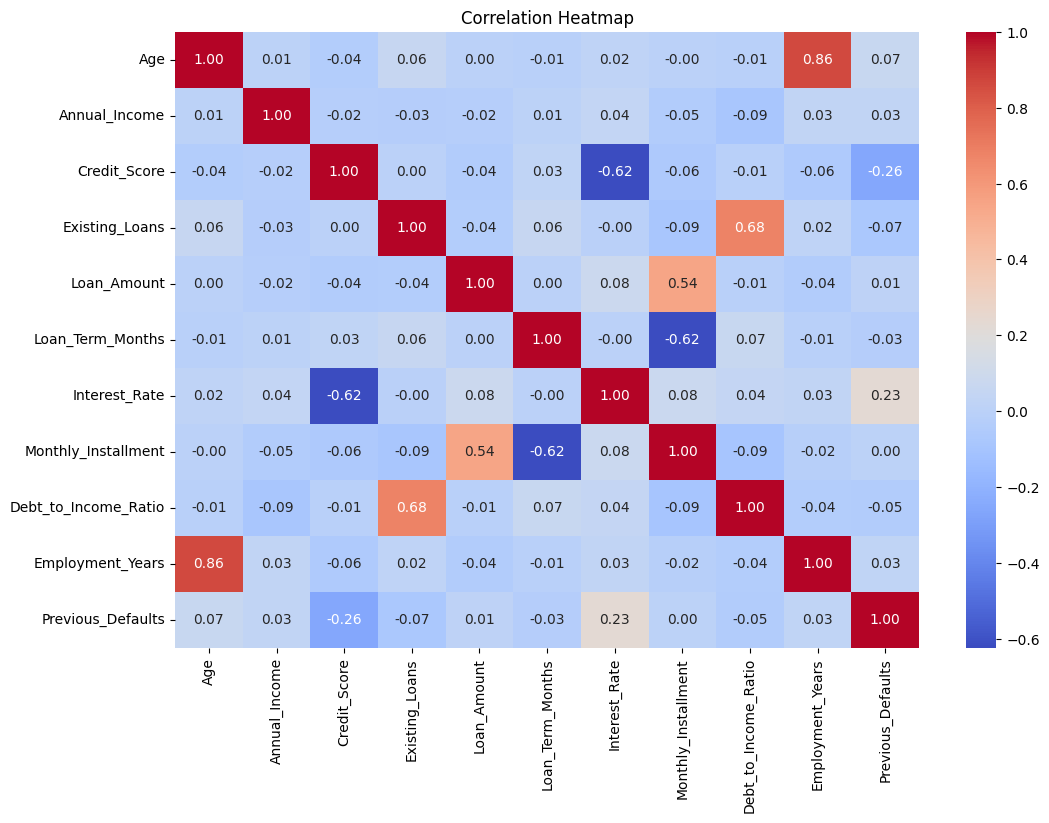


LOAN DEFAULT ANALYSIS COMPLETED
Total Rows: 500
Total Columns: 26
Total Defaulted Loans: 276
Overall Default Rate: 55.2 %


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#PART 1-DATA LOADING
df=pd.read_csv("loan_default_credit_risk_analysis_cleaned.csv")
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
#PART 2 DATA EXPLORATION & CLEANING
print(df.dtypes)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.drop_duplicates(inplace=True))
print(df.duplicated().sum())
print(df["Gender"].unique())
print(df["Education"].unique())
print(df["Loan_Type"].unique())
print(df["Default_Status"].unique())
numeric_columns=df.select_dtypes(include=np.number).columns
for column in numeric_columns:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[column])
  plt.title("outlier check-"+column)
  plt.show()
  print(df.shape)
  print(df.isnull().sum().sum())
  print(df.duplicated().sum())
#PART 3 DATA ANALYSIS
total_customers=df["Customer_ID"].nunique()
print(total_customers)
total_loans=df["Loan_ID"].nunique()
print(total_loans)
defaulted_loans=(df["Default_Status"]=="Deffault").sum()
print(defaulted_loans)
non_defauted_loans=(df["Default_Status"]=="No Default").sum()
print(non_defauted_loans)
default_rate=(df["Default_Status"]=="Default").mean()*00
print(default_rate,2)
print(df["Credit_Score"].mean(),2)
print(df["Loan_Amount"].mean(),2)
print(df["Interest_Rate"].mean(),2)
print(df["Debt_to_Income_Ratio"].mean(),2)
loan_type_count=df["Loan_Type"].value_counts()
print(loan_type_count)
region_count=df["Region"].value_counts()
print(region_count)
# ------------------------------------------------------------
# 28. Calculate default rate by loan type
# ------------------------------------------------------------

default_by_loan_type = df.groupby('Loan_Type')['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n28. Default Rate by Loan Type:")
print(default_by_loan_type.round(2))


# ------------------------------------------------------------
# 29. Calculate default rate by employment status
# ------------------------------------------------------------

default_by_employment = df.groupby('Employment_Status')['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n29. Default Rate by Employment Status:")
print(default_by_employment.round(2))


# ------------------------------------------------------------
# 30. Calculate default rate by education
# ------------------------------------------------------------

default_by_education = df.groupby('Education')['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n30. Default Rate by Education:")
print(default_by_education.round(2))


# ------------------------------------------------------------
# 31. Calculate default rate by property ownership
# ------------------------------------------------------------

default_by_property = df.groupby('Property_Ownership')['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n31. Default Rate by Property Ownership:")
print(default_by_property.round(2))


# ------------------------------------------------------------
# 32. Calculate default rate by credit-score group
# ------------------------------------------------------------

df['Credit_Score_Group'] = pd.cut(
    df['Credit_Score'],
    bins=[-np.inf, 599, 699, 749, np.inf],
    labels=[
        'Low (<600)',
        'Medium (600-699)',
        'Good (700-749)',
        'Excellent (750+)'
    ]
)

default_by_credit_group = df.groupby(
    'Credit_Score_Group',
    observed=False
)['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n32. Default Rate by Credit Score Group:")
print(default_by_credit_group.round(2))


# ------------------------------------------------------------
# 33. Calculate default rate by income group
# ------------------------------------------------------------

df['Income_Group'] = pd.qcut(
    df['Annual_Income'],
    q=3,
    labels=[
        'Low Income',
        'Medium Income',
        'High Income'
    ]
)

default_by_income_group = df.groupby(
    'Income_Group',
    observed=False
)['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n33. Default Rate by Income Group:")
print(default_by_income_group.round(2))


# ------------------------------------------------------------
# 34. Find customers with below-average credit scores
# ------------------------------------------------------------

average_credit_score = df['Credit_Score'].mean()

below_average_credit = df[
    df['Credit_Score'] < average_credit_score
]

print("\n34. Customers with Below-Average Credit Scores:")
print(
    below_average_credit[
        [
            'Customer_ID',
            'Credit_Score',
            'Loan_Amount',
            'Default_Status'
        ]
    ]
)


# ------------------------------------------------------------
# 35. Find customers with above-average loan amounts
# ------------------------------------------------------------

average_loan_amount = df['Loan_Amount'].mean()

above_average_loan = df[
    df['Loan_Amount'] > average_loan_amount
]

print("\n35. Customers with Above-Average Loan Amounts:")
print(
    above_average_loan[
        [
            'Customer_ID',
            'Loan_Amount',
            'Credit_Score',
            'Default_Status'
        ]
    ]
)


# ------------------------------------------------------------
# 36. Find customers with high debt-to-income ratios
# ------------------------------------------------------------

average_dti = df['Debt_to_Income_Ratio'].mean()

high_dti = df[
    df['Debt_to_Income_Ratio'] > average_dti
]

print("\n36. Customers with High Debt-to-Income Ratios:")
print(
    high_dti[
        [
            'Customer_ID',
            'Debt_to_Income_Ratio',
            'Loan_Amount',
            'Default_Status'
        ]
    ]
)


# ------------------------------------------------------------
# 37. Find top 10 customers based on loan amount
# ------------------------------------------------------------

top_10_customers = df.nlargest(
    10,
    'Loan_Amount'
)

print("\n37. Top 10 Customers Based on Loan Amount:")
print(
    top_10_customers[
        [
            'Customer_ID',
            'Loan_Amount',
            'Loan_Type',
            'Credit_Score',
            'Default_Status'
        ]
    ]
)


# ------------------------------------------------------------
# 38. Find loan type with highest default rate
# ------------------------------------------------------------

highest_default_loan_type = default_by_loan_type.idxmax()
highest_default_loan_rate = default_by_loan_type.max()

print("\n38. Loan Type with Highest Default Rate:")
print("Loan Type:", highest_default_loan_type)
print("Default Rate:", round(highest_default_loan_rate, 2), "%")


# ------------------------------------------------------------
# 39. Find region with highest default rate
# ------------------------------------------------------------

default_by_region = df.groupby('Region')['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

highest_default_region = default_by_region.idxmax()
highest_region_rate = default_by_region.max()

print("\n39. Region with Highest Default Rate:")
print("Region:", highest_default_region)
print("Default Rate:", round(highest_region_rate, 2), "%")


# ------------------------------------------------------------
# 40. Analyze credit score vs default
# ------------------------------------------------------------

credit_score_vs_default = df.groupby(
    'Default_Status'
)['Credit_Score'].mean()

print("\n40. Average Credit Score by Default Status:")
print(credit_score_vs_default.round(2))


# ------------------------------------------------------------
# 41. Analyze income vs default
# ------------------------------------------------------------

income_vs_default = df.groupby(
    'Default_Status'
)['Annual_Income'].mean()

print("\n41. Average Income by Default Status:")
print(income_vs_default.round(2))


# ------------------------------------------------------------
# 42. Analyze loan amount vs default
# ------------------------------------------------------------

loan_amount_vs_default = df.groupby(
    'Default_Status'
)['Loan_Amount'].mean()

print("\n42. Average Loan Amount by Default Status:")
print(loan_amount_vs_default.round(2))


# ------------------------------------------------------------
# 43. Analyze previous defaults vs current default
# ------------------------------------------------------------

previous_defaults_vs_current = df.groupby(
    'Previous_Defaults'
)['Default_Status'].apply(
    lambda x: (x == 'Default').mean() * 100
)

print("\n43. Default Rate by Previous Defaults:")
print(previous_defaults_vs_current.round(2))


# ------------------------------------------------------------
# 44. Identify important patterns associated with loan default
# ------------------------------------------------------------

print("\n44. IMPORTANT PATTERNS ASSOCIATED WITH LOAN DEFAULT")

print(
    "\nOverall Default Rate:",
    round((df['Default_Status'] == 'Default').mean() * 100, 2),
    "%"
)

print(
    "Loan Type with Highest Default Rate:",
    highest_default_loan_type
)

print(
    "Region with Highest Default Rate:",
    highest_default_region
)

print(
    "Average Credit Score:",
    round(df['Credit_Score'].mean(), 2)
)

print(
    "Average Loan Amount:",
    round(df['Loan_Amount'].mean(), 2)
)

print(
    "Average Debt-to-Income Ratio:",
    round(df['Debt_to_Income_Ratio'].mean(), 2),
    "%"
)


# ============================================================
# PART 4 — PYTHON VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# 1. Loan Default Distribution — Pie Chart
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))

df['Default_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Loan Default Distribution')
plt.ylabel('')
plt.show()


# ------------------------------------------------------------
# 2. Loan Count by Loan Type — Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

df['Loan_Type'].value_counts().plot(
    kind='bar'
)

plt.title('Loan Count by Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 3. Default Rate by Loan Type — Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

default_by_loan_type.plot(
    kind='bar'
)

plt.title('Default Rate by Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 4. Default Rate by Employment Status — Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

default_by_employment.plot(
    kind='bar'
)

plt.title('Default Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 5. Default Rate by Education — Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

default_by_education.plot(
    kind='bar'
)

plt.title('Default Rate by Education')
plt.xlabel('Education')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.show()


# ------------------------------------------------------------
# 6. Credit Score Distribution — Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df['Credit_Score'],
    bins=20
)

plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.show()


# ------------------------------------------------------------
# 7. Loan Amount Distribution — Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df['Loan_Amount'],
    bins=20
)

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Loans')
plt.show()


# ------------------------------------------------------------
# 8. Annual Income Distribution — Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    df['Annual_Income'],
    bins=20
)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Number of Customers')
plt.show()


# ------------------------------------------------------------
# 9. Credit Score vs Loan Amount — Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Credit_Score'],
    df['Loan_Amount']
)

plt.title('Credit Score vs Loan Amount')
plt.xlabel('Credit Score')
plt.ylabel('Loan Amount')
plt.show()


# ------------------------------------------------------------
# 10. Income vs Loan Amount — Scatter Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Annual_Income'],
    df['Loan_Amount']
)

plt.title('Income vs Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.show()


# ------------------------------------------------------------
# 11. Loan Amount by Default Status — Box Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Default_Status',
    y='Loan_Amount',
    data=df
)

plt.title('Loan Amount by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Loan Amount')
plt.show()


# ------------------------------------------------------------
# 12. Credit Score by Default Status — Box Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Default_Status',
    y='Credit_Score',
    data=df
)

plt.title('Credit Score by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Credit Score')
plt.show()


# ------------------------------------------------------------
# 13. Debt-to-Income Ratio by Default Status — Box Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Default_Status',
    y='Debt_to_Income_Ratio',
    data=df
)

plt.title('Debt-to-Income Ratio by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Debt-to-Income Ratio')
plt.show()


# ------------------------------------------------------------
# 14. Default Rate by Income Group — Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

default_by_income_group.plot(
    kind='bar'
)

plt.title('Default Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=0)
plt.show()


# ------------------------------------------------------------
# 15. Correlation Heatmap
# ------------------------------------------------------------

correlation_columns = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Existing_Loans',
    'Loan_Amount',
    'Loan_Term_Months',
    'Interest_Rate',
    'Monthly_Installment',
    'Debt_to_Income_Ratio',
    'Employment_Years',
    'Previous_Defaults'
]

correlation = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


# ============================================================
# PROJECT COMPLETED
# ============================================================

print("\n========================================")
print("LOAN DEFAULT ANALYSIS COMPLETED")
print("========================================")
print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Defaulted Loans:",
      (df['Default_Status'] == 'Default').sum())
print("Overall Default Rate:",
      round((df['Default_Status'] == 'Default').mean() * 100, 2), "%")
print("========================================")


